# Assignment 5 -- Reed Baumgardner
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [1]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [2]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [3]:
print(A @ e_1)
print(A @ e_2)
print(A @ e_3)

[1 4 7]
[2 5 8]
[3 6 9]


For e1, only x1 = 1 is nonzero, so we take the first column from A, and this is the same for e2 and e3 with column 2 and 3. In general, multiplying A by a standard basis vector such as e_j selects the j-th column of A because matrix multiplication forms a weighted sum of the columns of A, and only one entry in e_j is nonzero.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [5]:
u = np.ones(3)

print(A @ u)

[ 6. 15. 24.]


When we do this multiplication, each entry in the output is the sum of the entries in the corresponding row of A. Since each entry in u = 1, each entry in the output is the sum of the elements in each respective row of A. So 1+2+3=6, 4+5+6=15 and 7+8+9=24.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [6]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])

print(A @ x)

[-2  4 11]


Multiplying by the identity matrix leaves the array/matrix unchanged. As we discussed previously, the 1s in the matrix are "selecting" components from the array. The first row of A has a 1 in the first column, second in the second etc. Because of this, the first 1 selects the first value in x (x1), so on and so forth.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [7]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

print(A @ x)


[11 -2  4]


In the same way an identity matrix selects the first row first second second etc, this matrix chooses the value but in a different order. Here, the third row of the first column of A contains the 1, not the first column, and thus it selects the third column (value) from the array x (11) and places it in the first column in the output array. Going down, the second column selects the first value and third column selects the second value. This is a permutation matrix.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [8]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


Each of these columns represent the probability distribution of moving from state j to all possible states after one transition. Thus, each column sums uo to 1. Ae1 shows the probabilities of moving from state 1 to other states, Ae2 from state 2 etc.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [12]:
rng = np.random.default_rng(100)
A = rng.random((3,3))
sums = np.sum(A,axis=0)
A = A/sums

e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

e1_f = e_1.copy()
e2_f = e_2.copy()
e3_f = e_3.copy()

for i in range(5):
    e1_f = A @ e1_f
    e2_f = A @ e2_f
    e3_f = A @ e3_f

print(e1_f)
print(e2_f)
print(e3_f)

[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


All three vectors are now very close to eachother despite starting in different states. With each iteration of multiplication, the vectors would become even closer to a single vector representing the stationary distribution.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [13]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

v = np.array([1,0])
v1 = v @ T
print(v1)

[0.25 0.5 ]


\begin{aligned}
v^{(1)} &= v T \\
&= [1, 0] 
\begin{bmatrix} 
0.25 & 0.5 \\ 
0.75 & 0.5 
\end{bmatrix} \\
&= [1 \cdot 0.25 + 0 \cdot 0.75,\ 1 \cdot 0.5 + 0 \cdot 0.5] \\
&= [0.25, 0.5]
\end{aligned}

This represents the proportions of the population in each state after one transition

In [14]:
v2 = v1 @ T
print(v2)

[0.4375 0.375 ]


This is a forecast of the proportions after two transitions. Each element in this vector shows the fraction of the population in each state at period 2.

In [16]:
v_current = np.array([1,0])
for i in range(15):
    v_current = v_current @ T
    print(v_current)

[0.25 0.5 ]
[0.4375 0.375 ]
[0.390625 0.40625 ]
[0.40234375 0.3984375 ]
[0.39941406 0.40039062]
[0.40014648 0.39990234]
[0.39996338 0.40002441]
[0.40000916 0.3999939 ]
[0.39999771 0.40000153]
[0.40000057 0.39999962]
[0.39999986 0.4000001 ]
[0.40000004 0.39999998]
[0.39999999 0.40000001]
[0.4 0.4]
[0.4 0.4]


It settles down at around the 14th loop, although even starting at the 6 or 7th iteration it is not changing a lot at all.

In [17]:
v_current = np.array([0,1])
for i in range(15):
    v_current = v_current @ T
    print(v_current)

[0.75 0.5 ]
[0.5625 0.625 ]
[0.609375 0.59375 ]
[0.59765625 0.6015625 ]
[0.60058594 0.59960938]
[0.59985352 0.60009766]
[0.60003662 0.59997559]
[0.59999084 0.6000061 ]
[0.60000229 0.59999847]
[0.59999943 0.60000038]
[0.60000014 0.5999999 ]
[0.59999996 0.60000002]
[0.60000001 0.59999999]
[0.6 0.6]
[0.6 0.6]


Yes, I get a different result (0.6 as opposed to 0.4). 0.6 + 0.4 = 1.00 which I have an inkling is related!

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [2]:
import pandas as pd
df = pd.read_csv("cville_weather.csv")
df.head()

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [22]:
# Checking missing values
df.isna().sum()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64

In [28]:
df.tail()

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,rain
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,0
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,0
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,0
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,0
410,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-02-01,2.0,",,N",0.6,",,N",NaN,NaN,NaN,NaN,NaN,NaN,0


Yes, I would say there are missing data issues present. Many columns have nearly 400 or more missing values, and there are only 411 rows in the dataframe. 

In [ ]:
# adding rain variable
df['rain'] = (df['PRCP'] > 0).astype(int)
df['rain'].head()

0    1
1    1
2    1
3    1
4    0
Name: rain, dtype: int64

In [31]:
# creating Markov chain

df['rainnext'] = df['rain'].shift(-1)

trans = pd.crosstab(df['rain'], df['rainnext'], dropna=True)

trans_matrix = trans.div(trans.sum(axis=1), axis=0)

print("Counts:")
print(trans)
print("\nProbabilities:")
print(trans_matrix)

Counts:
rainnext  0.0  1.0
rain              
0         169   62
1          63  116

Probabilities:
rainnext       0.0       1.0
rain                        
0         0.731602  0.268398
1         0.351955  0.648045


If it was rainy yesterday: Prob of rain today is 0.648 (64.8%)

If it was clear yesterday: Prob of rain today is 0.268 (26.8%)

In [ ]:
T = np.array([[0.731602, 0.268398],
              [0.351955, 0.648045]])

v_clear = np.array([1, 0])
v_rain = np.array([0, 1])

print("Forecast starting from a clear day:")
v = v_clear.copy()
for i in range(20):
    v = v @ T
    print(f"Day {i+1}: {v}")

print("\nForecast starting from a rainy day:")
v = v_rain.copy()
for i in range(20):
    v = v @ T
    print(f"Day {i+1}: {v}")

It converges to a fixed result around day 20. Starting from a clear day, day 1 probability of rain starts low (around 27%), but increases as days increase. Conversely, starting from a rainy day starts day 1 around 65% and becomes lower with every day before they both converge on ~[0.567, 0.433]

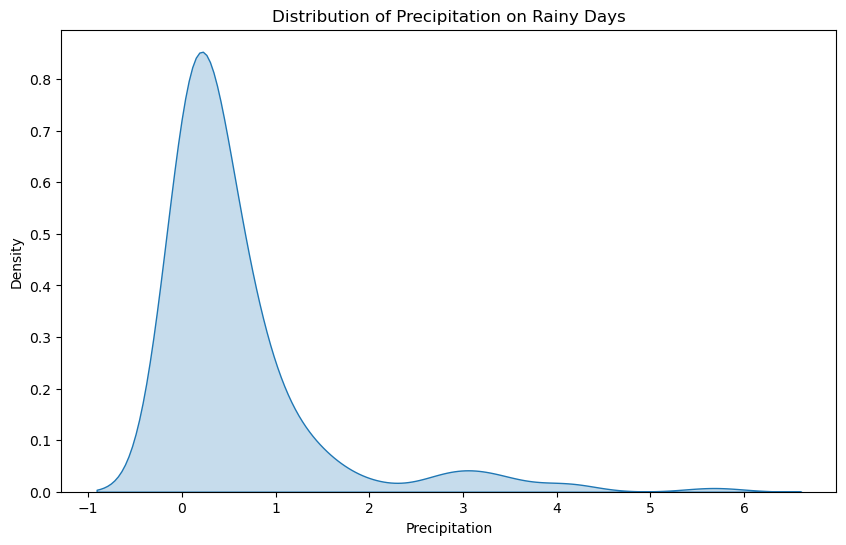

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

rainydays = df[df['rain']==1]

plt.figure(figsize=(10,6))
sns.kdeplot(rainydays['PRCP'].dropna(), fill=True)
plt.title("Distribution of Precipitation on Rainy Days")
plt.xlabel("Precipitation")
plt.ylabel("Density")
plt.show()

I would note a few things that is impacting our model's success:
- the two state, firt order Markov chain is only considering yesterday's weather to predict today. This ignores longer term patterns such as seasonal trends and could be subject to outliers. It should be possible to add higher orders to the Markov chain to perhaps consider the past week of weather instead, perhaps weighting days closer to today, though.
- Only using precipitation as a variable is limiting when, with better data, we could include other variables such as temperature and pressure.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [11]:
df = pd.read_pickle("taxicab.pkl")


In [ ]:
all_states = sorted(set().union(*[ride.unique() for ride in df]))
len(all_states), all_states[:38]

In [24]:
cleaned_trips = []

for ride in df:
    ride = ride.dropna()
    ride = ride[ride != "Unknown"]
    ride = ride[ride != "Outside Manhattan"]
    
    ride = ride[ride.shift() != ride]
    
    if len(ride) > 1:
        cleaned_trips.append(ride.reset_index(drop=True))

len(cleaned_trips)

997

In [25]:
trans = [
    pair
    for trip in cleaned_trips
    for pair in zip(trip[:-1], trip[1:])
]

trans_df = pd.DataFrame(trans, columns=["from", "to"])
trans_df.head()

,from,to
0,Central Park,Upper East Side
1,Upper East Side,Upper West Side
2,Upper West Side,Lower East Side
3,Lower East Side,Gramercy
4,Gramercy,Kips Bay


In [26]:
counts = pd.crosstab(trans_df["from"], trans_df["to"], dropna=True)
trans_matrix = counts.div(counts.sum(axis=1), axis=0)
trans_matrix.head()

to,Battery Park City,Central Park,Chelsea,Chinatown,Civic Center,East Harlem,East Village,Ellis Island,Financial District,Flatiron District,...,Roosevelt Island,SoHo,Stuyvesant Town,Theater District,Tribeca,Two Bridges,Upper East Side,Upper West Side,Washington Heights,West Village
from,,,,,,,,,,,,,,,,,,,,,
Battery Park City,0.000000,0.004174,0.099700,0.010551,0.007188,0.003618,0.031149,0.0,0.128890,0.014601,...,0.000278,0.075188,0.004364,0.034110,0.163692,0.001439,0.041262,0.027934,0.001332,0.084442
Central Park,0.003614,0.000000,0.038678,0.001379,0.000850,0.022404,0.009039,0.0,0.006246,0.008057,...,0.000214,0.007660,0.001303,0.044071,0.005573,0.000201,0.235162,0.260459,0.003139,0.011145
Chelsea,0.013441,0.008957,0.000000,0.005332,0.003186,0.007217,0.045223,0.0,0.019604,0.045790,...,0.000380,0.036217,0.005804,0.058040,0.023854,0.000408,0.068074,0.053798,0.003466,0.095915
Chinatown,0.016082,0.003382,0.058852,0.000000,0.031357,0.005368,0.106030,0.0,0.072600,0.010082,...,0.000436,0.076440,0.007583,0.021461,0.060544,0.003099,0.038231,0.018308,0.001560,0.040741
Civic Center,0.028581,0.003460,0.060910,0.040033,0.000000,0.005277,0.057488,0.0,0.127459,0.013115,...,0.000325,0.080180,0.004952,0.022119,0.157704,0.003977,0.040606,0.016824,0.001721,0.045654


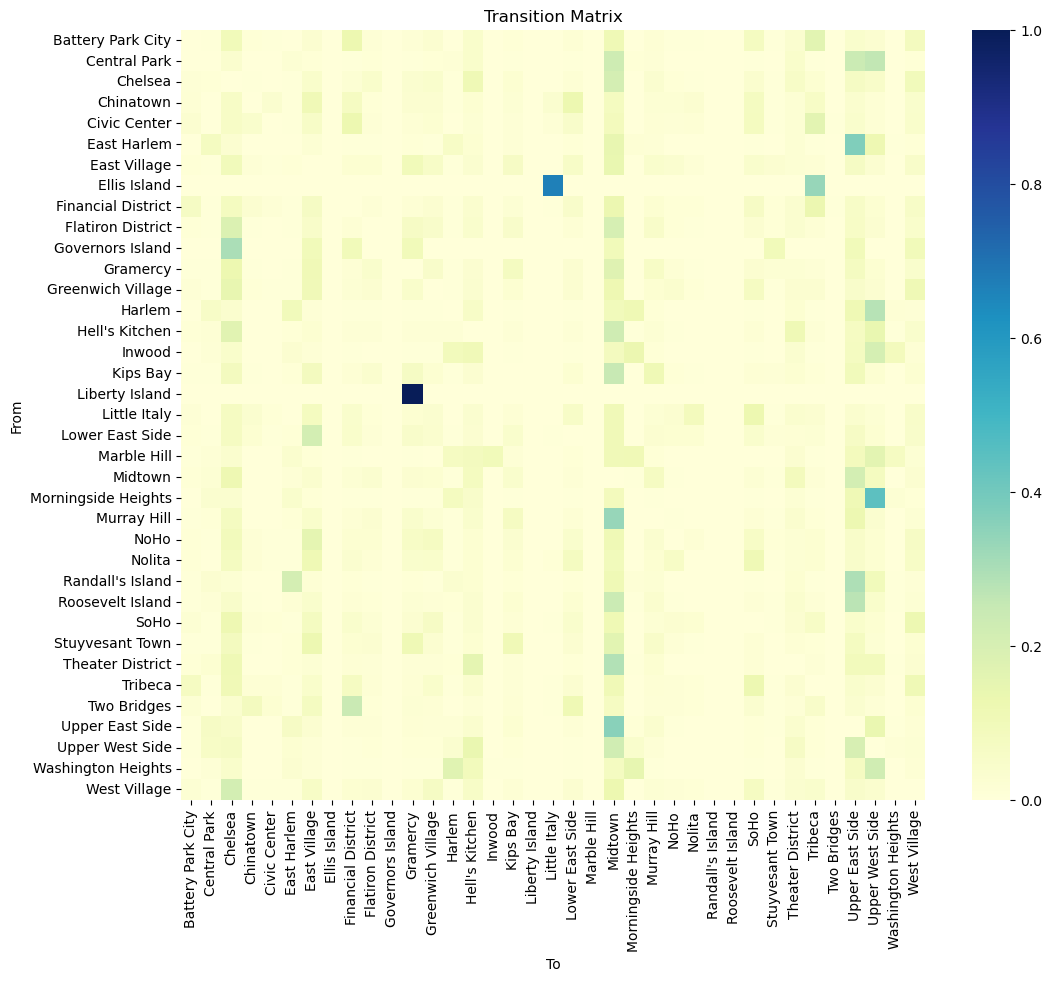

In [30]:
# Plotting

plt.figure(figsize=(12,10))
sns.heatmap(trans_matrix, cmap="YlGnBu")
plt.title("Transition Matrix")
plt.xlabel("To")
plt.ylabel("From")
plt.show()

In [31]:
most_common_routes = (
    trans_df.value_counts()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

most_common_routes

,from,to,count
0,Upper East Side,Midtown,534442
1,Midtown,Upper East Side,518504
2,Midtown,Chelsea,290090
3,Chelsea,Midtown,274906
4,Upper West Side,Midtown,230348
5,Midtown,Theater District,210309
6,Upper West Side,Upper East Side,204175
7,Upper East Side,Upper West Side,203082
8,Theater District,Midtown,195458
9,Hell's Kitchen,Midtown,195437


### Explaining why taxi rides are first order usually
For starters, a taxi ride is usually one stop: From point A to point B. Thus, the next neighborhood a taxi moves to is primarily dependent on its current location and not the full sequence of previous stops. Because each new rider that gets in has a different place to go independent of the stranger beforehand.

In [35]:
states = trans_matrix.index.tolist()

start = np.zeros(len(states))
start[states.index("Hell's Kitchen")] = 1

def forecasts(start, trans_matrix, n):
    current = start.copy()
    results = []

    for i in range(n):
        current = current @ trans_matrix.values
        results.append(current.copy())

    return results

forecast_list = forecasts(start, trans_matrix, 10)

forecasts_df = pd.DataFrame(forecast_list, columns=states)
forecasts_df.head(10)

,Battery Park City,Central Park,Chelsea,Chinatown,Civic Center,East Harlem,East Village,Ellis Island,Financial District,Flatiron District,...,Roosevelt Island,SoHo,Stuyvesant Town,Theater District,Tribeca,Two Bridges,Upper East Side,Upper West Side,Washington Heights,West Village
0,0.010303,0.017328,0.164523,0.003663,0.001875,0.009601,0.024131,0.000000e+00,0.014672,0.015034,...,0.000379,0.017693,0.002623,0.113149,0.014408,0.000305,0.073561,0.138785,0.006759,0.041972
1,0.011209,0.025367,0.083342,0.005391,0.003195,0.017186,0.039293,1.854695e-07,0.019771,0.024835,...,0.000514,0.026799,0.005560,0.048923,0.019960,0.000545,0.121916,0.067806,0.004938,0.041999
2,0.011633,0.023460,0.094683,0.006138,0.003532,0.018405,0.043896,2.088402e-07,0.020830,0.022840,...,0.000501,0.027878,0.006394,0.050229,0.020839,0.000640,0.104718,0.079949,0.004510,0.040737
3,0.011816,0.023010,0.092304,0.006360,0.003640,0.017478,0.045108,2.102681e-07,0.021268,0.023532,...,0.000499,0.028634,0.006637,0.048962,0.021342,0.000662,0.108535,0.073877,0.004431,0.041838
4,0.011907,0.022734,0.092930,0.006444,0.003681,0.017519,0.045603,2.114718e-07,0.021443,0.023492,...,0.000498,0.028915,0.006709,0.048685,0.021539,0.000671,0.106255,0.074185,0.004372,0.042005
5,0.011948,0.022607,0.092961,0.006478,0.003698,0.017367,0.045774,2.123962e-07,0.021517,0.023565,...,0.000498,0.029042,0.006737,0.048646,0.021630,0.000674,0.106519,0.073608,0.004356,0.042159
6,0.011966,0.022564,0.093004,0.006491,0.003705,0.017357,0.045849,2.125383e-07,0.021547,0.023570,...,0.000498,0.029093,0.006747,0.048592,0.021667,0.000675,0.106232,0.073548,0.004347,0.042211
7,0.011973,0.022541,0.093025,0.006497,0.003708,0.017336,0.045877,2.127049e-07,0.021560,0.023579,...,0.000497,0.029115,0.006752,0.048587,0.021683,0.000676,0.106241,0.073478,0.004344,0.042234
8,0.011977,0.022533,0.093031,0.006499,0.003709,0.017332,0.045890,2.127333e-07,0.021565,0.023581,...,0.000497,0.029124,0.006753,0.048579,0.021690,0.000676,0.106203,0.073461,0.004343,0.042244
9,0.011978,0.022530,0.093035,0.006500,0.003709,0.017329,0.045895,2.127598e-07,0.021567,0.023582,...,0.000497,0.029128,0.006754,0.048578,0.021693,0.000676,0.106201,0.073450,0.004342,0.042248


In [36]:
trip_num = [2,3,5,10]
for t in trip_num:
    print(f"Trip Number: {t}")
    print(forecasts_df.iloc[t-1].sort_values(ascending=False).head(5))
    print()

Trip Number: 2
Midtown            0.167757
Upper East Side    0.121916
Hell's Kitchen     0.086879
Chelsea            0.083342
Upper West Side    0.067806
Name: 1, dtype: float64

Trip Number: 3
Midtown            0.177327
Upper East Side    0.104718
Chelsea            0.094683
Upper West Side    0.079949
Hell's Kitchen     0.060040
Name: 2, dtype: float64

Trip Number: 5
Midtown            0.172850
Upper East Side    0.106255
Chelsea            0.092930
Upper West Side    0.074185
Hell's Kitchen     0.062085
Name: 4, dtype: float64

Trip Number: 10
Midtown            0.172094
Upper East Side    0.106201
Chelsea            0.093035
Upper West Side    0.073450
Hell's Kitchen     0.062089
Name: 9, dtype: float64



In [37]:
start = np.zeros(len(states))
start[states.index("Midtown")] = 1

tolerance = 1e-8
current = start.copy()
diff=1
iteration = 0

while diff > tolerance:
    next = current @ trans_matrix.values
    diff = np.sum(np.abs(next - current))
    current = next
    iteration += 1

print(f"Converged in {iteration} iterations")
print(current)

Converged in 20 iterations
[1.19787930e-02 2.25271258e-02 9.30364477e-02 6.50074294e-03
 3.70965402e-03 1.73275634e-02 4.58982580e-02 2.12772017e-07
 2.15686382e-02 2.35831739e-02 7.09249691e-07 2.93083148e-02
 2.82105288e-02 1.20647287e-02 6.20865477e-02 9.45275145e-04
 2.90350988e-02 7.09254542e-08 2.45718809e-03 2.04701944e-02
 3.38308966e-05 1.72091738e-01 9.23506912e-03 3.72461264e-02
 1.05734856e-02 6.34086211e-03 2.09793616e-04 4.97387559e-04
 2.91307366e-02 6.75453695e-03 4.85758672e-02 2.16945156e-02
 6.76200571e-04 1.06193437e-01 7.34440391e-02 4.34196727e-03
 4.22511396e-02]


In [38]:
stationary_dist = pd.Series(current, index=states).sort_values(ascending=False).head(10)
print("\nTop neighborhoods:")
print(stationary_dist.head(5))


Top neighborhoods:
Midtown            0.172092
Upper East Side    0.106193
Chelsea            0.093036
Upper West Side    0.073444
Hell's Kitchen     0.062087
dtype: float64
